# Análise Exploratória de Dados — Wine Quality

Este notebook tem como objetivo analisar dados físico-químicos de vinhos e preparar a base para um problema de Machine Learning de classificação binária.


## 1. Compreensão do Problema

O objetivo deste projeto é analisar características físico-químicas dos vinhos e verificar como elas se relacionam com a qualidade final.

A variável original de qualidade é `quality`, que representa a nota atribuída ao vinho. Como o trabalho pede uma classificação binária, essa variável será transformada em uma nova variável chamada `quality_binary`.

Nesta nova variável:
- `1` representa vinhos de alta qualidade, com nota maior ou igual a 7.
- `0` representa vinhos de qualidade baixa ou intermediária, com nota menor que 7.

Dessa forma, o problema passa a ser tratado como uma classificação binária: prever se um vinho pertence ou não ao grupo de alta qualidade.


## 2. Importação das bibliotecas


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


ModuleNotFoundError: No module named 'numpy'

## 3. Carregamento da base de dados

A base utilizada é o arquivo `WineQT.csv`. No Google Colab, o arquivo precisa estar carregado no ambiente antes da execução desta célula.


In [ ]:
df = pd.read_csv('WineQT.csv')
df.head()


NameError: name 'pd' is not defined

## 4. Entendimento inicial da base

Nesta etapa são avaliados o tamanho da base, os tipos das colunas, a existência de valores nulos, registros duplicados e estatísticas descritivas.


In [ ]:
df.shape


(1143, 13)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [ ]:
df.isnull().sum()


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [ ]:
df.duplicated().sum()


np.int64(0)

In [ ]:
df.describe().round(2)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00,1143.00
mean,8.31,0.53,0.27,2.53,0.09,15.62,45.91,1.00,3.31,0.66,10.44,5.66,804.97
std,1.75,0.18,0.20,1.36,0.05,10.25,32.78,0.00,0.16,0.17,1.08,0.81,464.00
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00,0.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,21.00,1.00,3.20,0.55,9.50,5.00,411.00
50%,7.90,0.52,0.25,2.20,0.08,13.00,37.00,1.00,3.31,0.62,10.20,6.00,794.00
75%,9.10,0.64,0.42,2.60,0.09,21.00,61.00,1.00,3.40,0.73,11.10,6.00,1209.50
max,15.90,1.58,1.00,15.50,0.61,68.00,289.00,1.00,4.01,2.00,14.90,8.00,1597.00


A análise inicial permite verificar que a base possui variáveis numéricas relacionadas à composição físico-química dos vinhos. Também é possível observar se existem valores ausentes ou registros duplicados que poderiam prejudicar a análise.


## 5. Distribuição da variável original `quality`

Antes de transformar a variável alvo em binária, é importante observar como as notas originais estão distribuídas.


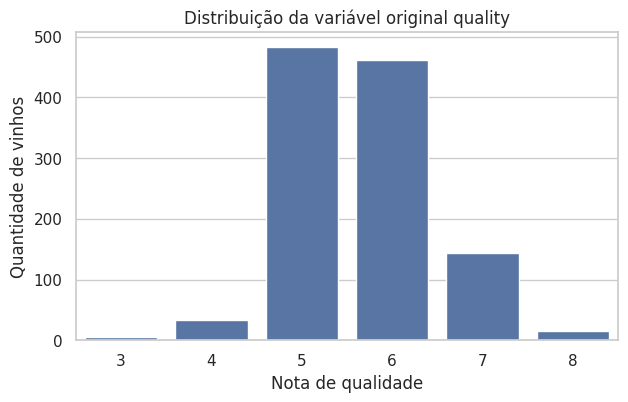

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='quality')
plt.title('Distribuição da variável original quality')
plt.xlabel('Nota de qualidade')
plt.ylabel('Quantidade de vinhos')
plt.show()


Observa-se concentração das amostras nas notas intermediárias, principalmente entre 5 e 6. Isso indica que a maioria dos vinhos da base não está nos extremos de qualidade.


## 6. Criação da variável alvo binária

A variável `quality_binary` será criada a partir da variável `quality`.

Critério adotado:
- `quality >= 7`: vinho de alta qualidade, classe `1`.
- `quality < 7`: vinho de qualidade baixa ou intermediária, classe `0`.


In [ ]:
df['quality_binary'] = np.where(df['quality'] >= 7, 1, 0)
df[['quality', 'quality_binary']].head()


,quality,quality_binary
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


## 7. Análise do balanceamento das classes

Depois da criação da variável binária, é necessário verificar se as classes estão equilibradas ou desbalanceadas.


In [ ]:
balanceamento = pd.DataFrame({
    'quantidade': df['quality_binary'].value_counts().sort_index(),
    'percentual': (df['quality_binary'].value_counts(normalize=True).sort_index() * 100).round(2)
})

balanceamento


,quantidade,percentual
quality_binary,,
0,984,86.09
1,159,13.91


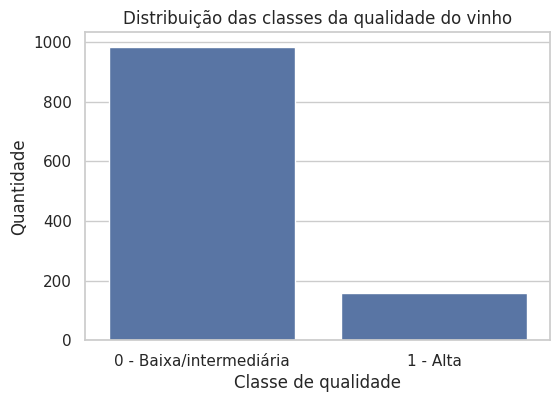

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='quality_binary')
plt.title('Distribuição das classes da qualidade do vinho')
plt.xlabel('Classe de qualidade')
plt.ylabel('Quantidade')
plt.xticks([0, 1], ['0 - Baixa/intermediária', '1 - Alta'])
plt.show()


A base está desbalanceada, pois há muito mais vinhos classificados como baixa/intermediária qualidade do que vinhos classificados como alta qualidade.

Esse desbalanceamento pode influenciar o modelo de Machine Learning, fazendo com que ele tenha maior tendência a prever a classe majoritária. Por isso, essa informação deve ser considerada nas próximas etapas de modelagem e avaliação.


## 8. Distribuição das variáveis numéricas

Nesta etapa, a distribuição das variáveis físico-químicas é analisada. As colunas `Id`, `quality` e `quality_binary` são removidas dessa visualização porque não representam atributos físico-químicos de entrada.


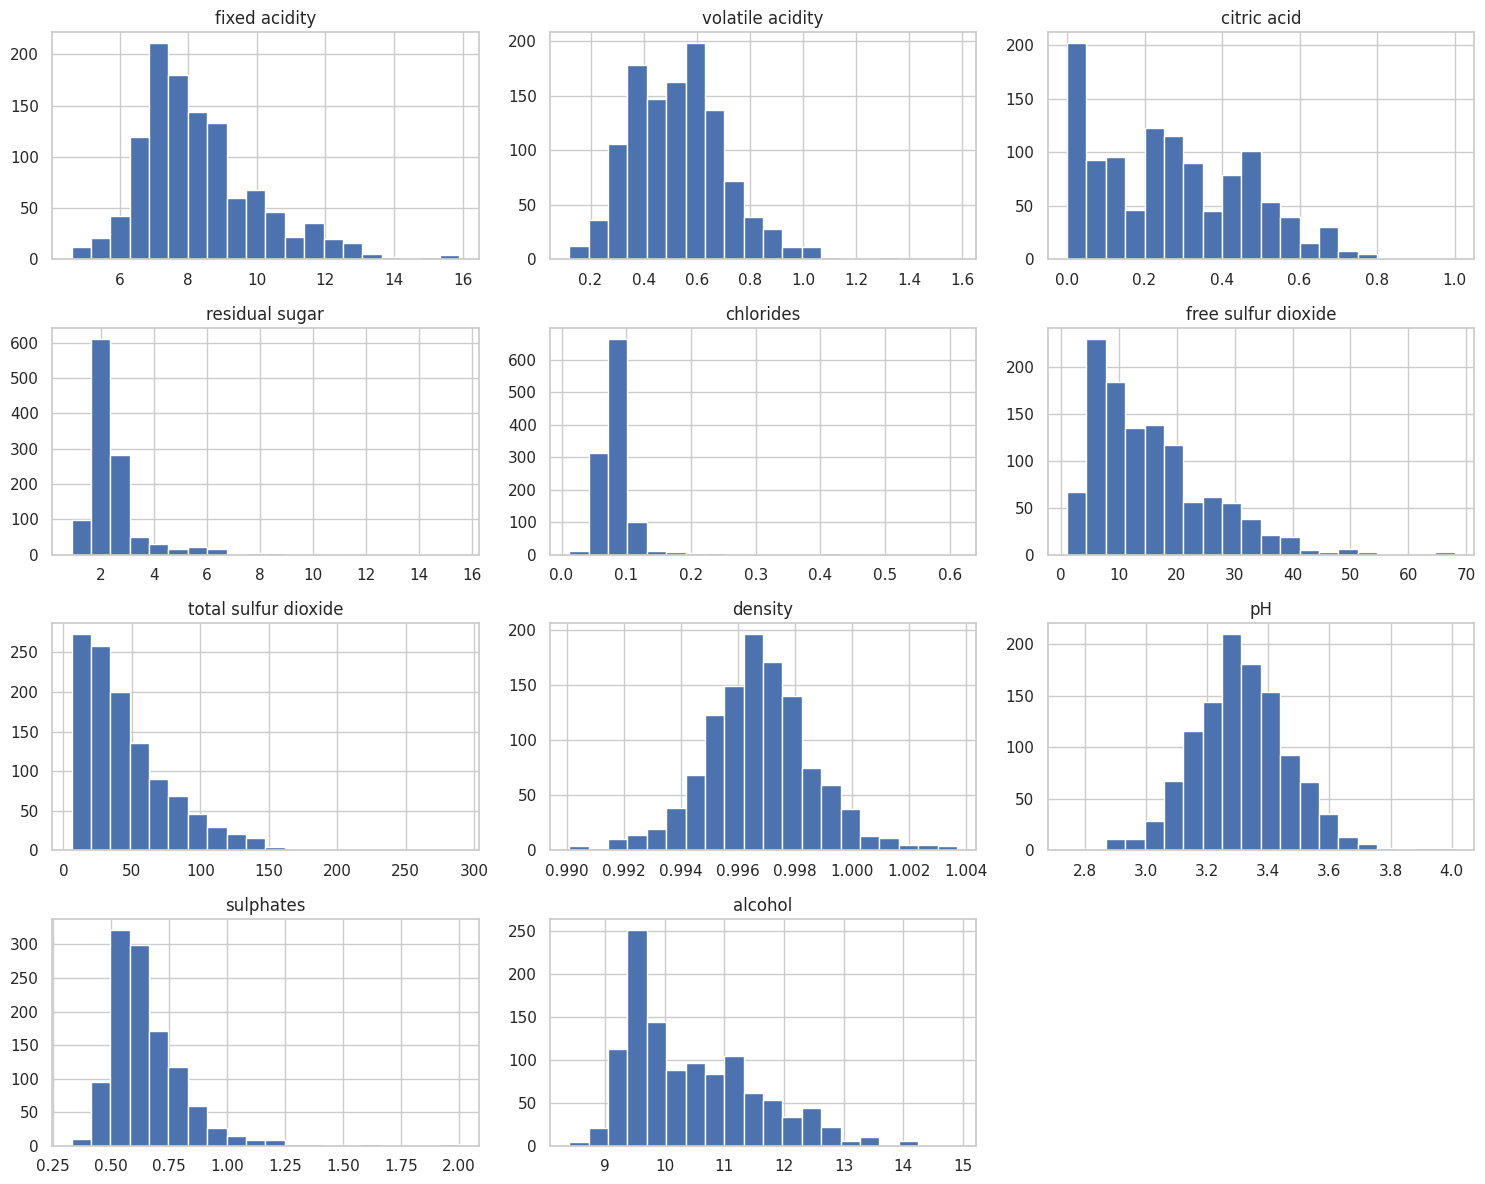

In [ ]:
variaveis_numericas = df.drop(columns=['Id', 'quality', 'quality_binary'])

variaveis_numericas.hist(
    figsize=(15, 12),
    bins=20
)

plt.tight_layout()
plt.show()


A análise dos histogramas mostra que algumas variáveis apresentam distribuição assimétrica, principalmente `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide` e `sulphates`.

A maior parte dos vinhos está concentrada em faixas menores dessas variáveis, mas existem alguns valores mais altos, indicando possível presença de outliers.

Também é possível observar que as variáveis possuem escalas diferentes. Esse ponto pode exigir padronização em algumas etapas de Machine Learning, dependendo do algoritmo utilizado.


## 9. Detecção de possíveis outliers

Os boxplots ajudam a visualizar valores extremos em cada variável. Em seguida, o método do intervalo interquartil, IQR, é utilizado para contar possíveis outliers.


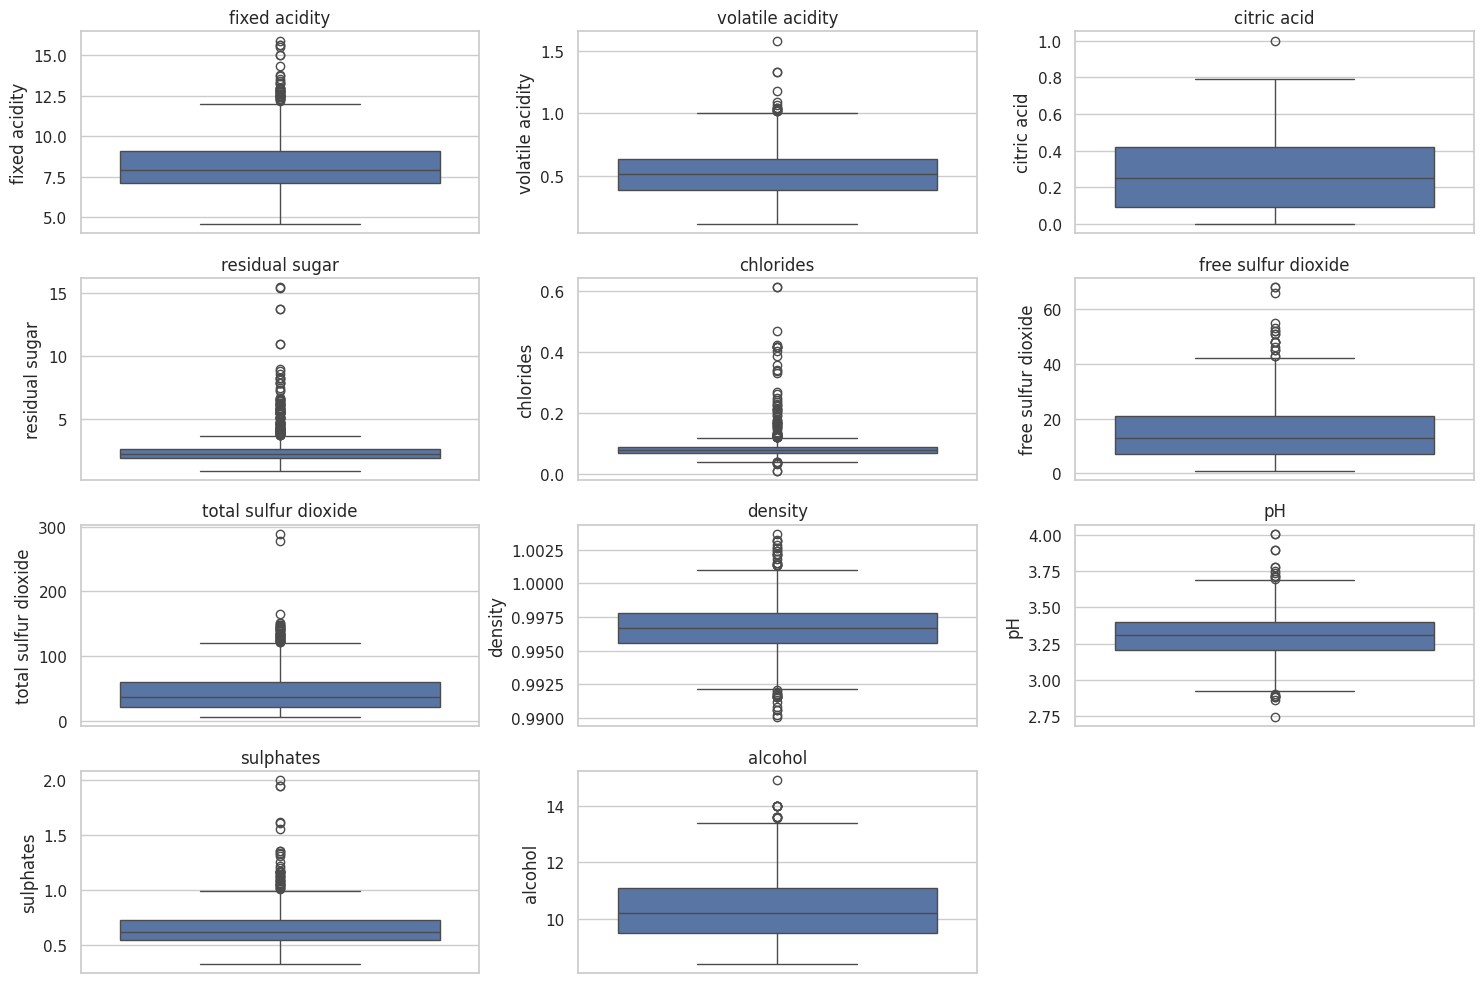

In [ ]:
plt.figure(figsize=(15, 10))

for i, col in enumerate(variaveis_numericas.columns):
    plt.subplot(4, 3, i + 1)
    sns.boxplot(y=variaveis_numericas[col])
    plt.title(col)

plt.tight_layout()
plt.show()


In [ ]:
Q1 = variaveis_numericas.quantile(0.25)
Q3 = variaveis_numericas.quantile(0.75)
IQR = Q3 - Q1

outliers = ((variaveis_numericas < (Q1 - 1.5 * IQR)) |
            (variaveis_numericas > (Q3 + 1.5 * IQR))).sum()

outliers.sort_values(ascending=False)


,0
residual sugar,110
chlorides,77
fixed acidity,44
sulphates,43
total sulfur dioxide,40
density,36
pH,20
free sulfur dioxide,18
volatile acidity,14
alcohol,12


A análise de outliers pelo método do intervalo interquartil permite identificar variáveis com maior quantidade de valores extremos.

Variáveis como `residual sugar`, `chlorides`, `fixed acidity`, `sulphates` e `total sulfur dioxide` tendem a apresentar mais valores discrepantes. Isso indica que a maioria dos vinhos possui valores concentrados em faixas menores, mas alguns registros estão acima ou abaixo do padrão observado na base.

A presença de outliers não significa necessariamente erro nos dados, pois esses valores podem representar características reais de determinados vinhos. Por isso, nesta etapa, os outliers serão apenas identificados e analisados, sem remoção automática.


## 10. Matriz de correlação

Nesta etapa, a coluna `Id` é removida porque é apenas um identificador. A coluna `quality` também é removida da análise principal de correlação com `quality_binary`, pois a variável binária foi criada a partir dela.

Assim, a correlação passa a considerar somente as variáveis físico-químicas e a variável alvo binária.


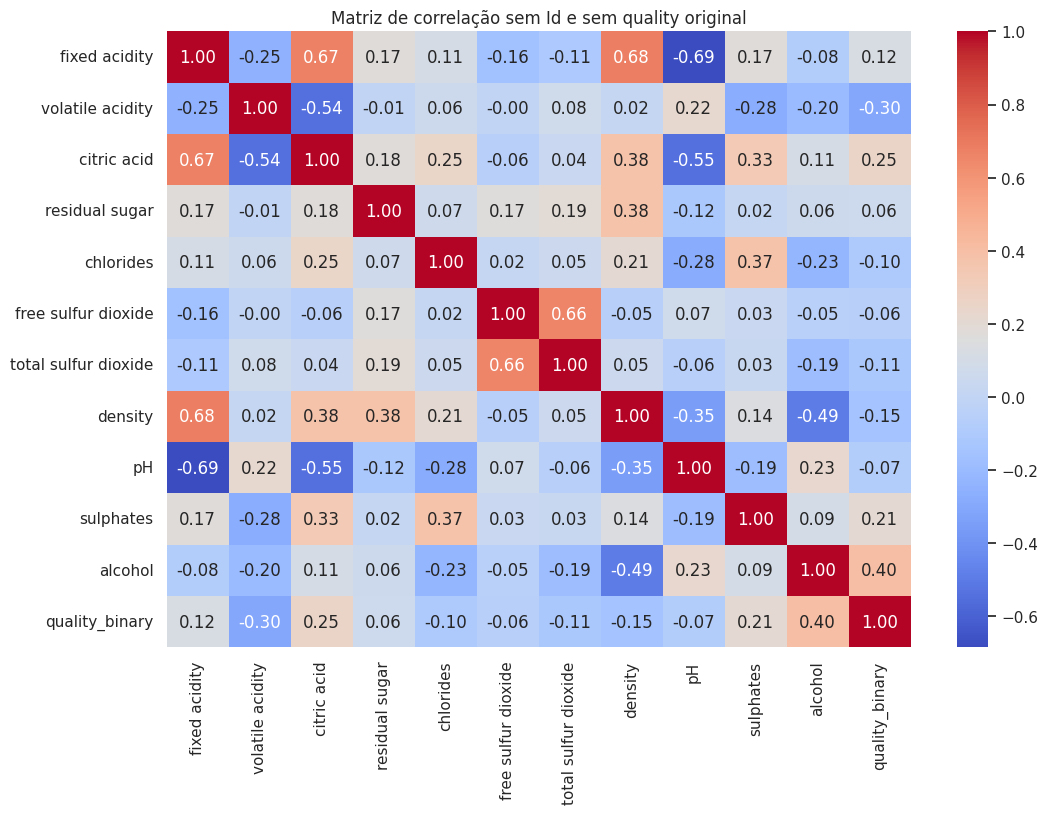

In [ ]:
df_corr = df.drop(columns=['Id', 'quality'])

plt.figure(figsize=(12, 8))
sns.heatmap(
    df_corr.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlação sem Id e sem quality original')
plt.show()


In [ ]:
corr_bin = (
    df_corr.corr(numeric_only=True)['quality_binary']
    .sort_values(ascending=False)
)

corr_bin


,quality_binary
quality_binary,1.000000
alcohol,0.403676
citric acid,0.251146
sulphates,0.208020
fixed acidity,0.123212
residual sugar,0.064145
free sulfur dioxide,-0.055977
pH,-0.073318
chlorides,-0.103985
total sulfur dioxide,-0.113373


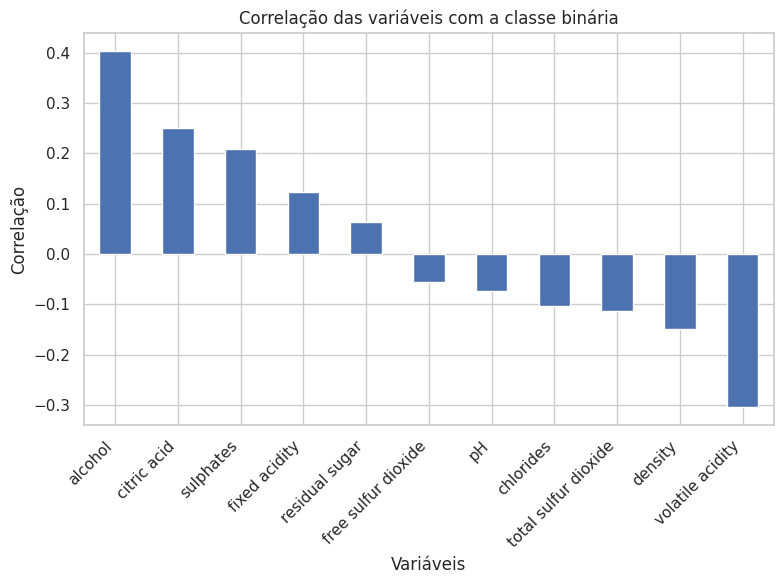

In [ ]:
plt.figure(figsize=(8, 6))

corr_bin.drop('quality_binary').plot(kind='bar')

plt.title('Correlação das variáveis com a classe binária')
plt.xlabel('Variáveis')
plt.ylabel('Correlação')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
corr_bin.drop('quality_binary').abs().sort_values(ascending=False).head(6)


,quality_binary
alcohol,0.403676
volatile acidity,0.304523
citric acid,0.251146
sulphates,0.208020
density,0.148670
fixed acidity,0.123212


A matriz de correlação mostra que a variável `alcohol` possui correlação positiva com a qualidade binária, indicando que vinhos com maior teor alcoólico tendem a estar mais associados à classe de alta qualidade.

A variável `volatile acidity` possui correlação negativa com a qualidade. Isso indica que, quanto maior a acidez volátil, menor tende a ser a qualidade do vinho. Esse comportamento é esperado, pois acidez volátil elevada pode prejudicar características sensoriais do vinho.

A variável `citric acid` apresenta correlação positiva com a qualidade binária. Isso sugere que vinhos com maior presença de ácido cítrico podem estar associados a maior frescor e equilíbrio.

A variável `sulphates` também apresenta correlação positiva, indicando que maiores concentrações dessa variável tendem a aparecer em vinhos de melhor qualidade.

A variável `density` apresenta correlação negativa com a qualidade. Isso pode estar relacionado ao teor alcoólico, já que vinhos com maior álcool tendem a apresentar menor densidade.

É importante destacar que correlação não significa causalidade. A análise mostra associação entre as variáveis, mas não prova que uma variável causa diretamente o aumento ou redução da qualidade.


## 11. Comparação de variáveis importantes por classe

Os boxplots abaixo comparam algumas variáveis relevantes entre as classes `0` e `1`.


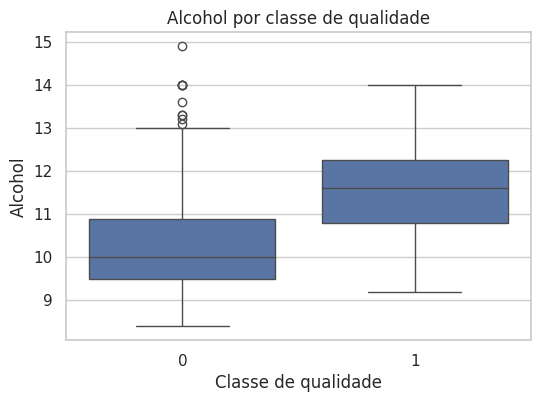

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='quality_binary', y='alcohol', data=df)
plt.title('Alcohol por classe de qualidade')
plt.xlabel('Classe de qualidade')
plt.ylabel('Alcohol')
plt.show()


Vinhos classificados como alta qualidade tendem a apresentar maior teor alcoólico quando comparados aos vinhos da classe baixa/intermediária.


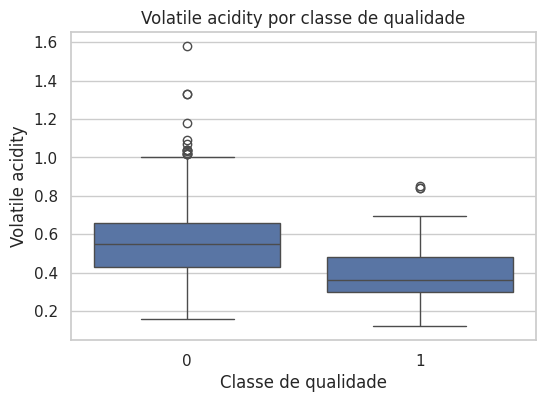

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='quality_binary', y='volatile acidity', data=df)
plt.title('Volatile acidity por classe de qualidade')
plt.xlabel('Classe de qualidade')
plt.ylabel('Volatile acidity')
plt.show()


A acidez volátil tende a ser menor nos vinhos classificados como alta qualidade, reforçando a correlação negativa observada anteriormente.


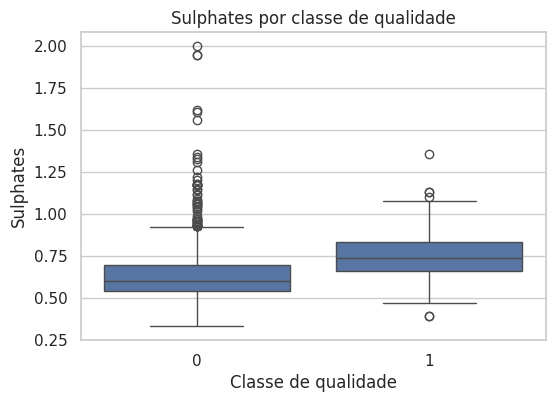

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='quality_binary', y='sulphates', data=df)
plt.title('Sulphates por classe de qualidade')
plt.xlabel('Classe de qualidade')
plt.ylabel('Sulphates')
plt.show()


Vinhos de melhor qualidade tendem a apresentar concentrações ligeiramente maiores de sulfatos.


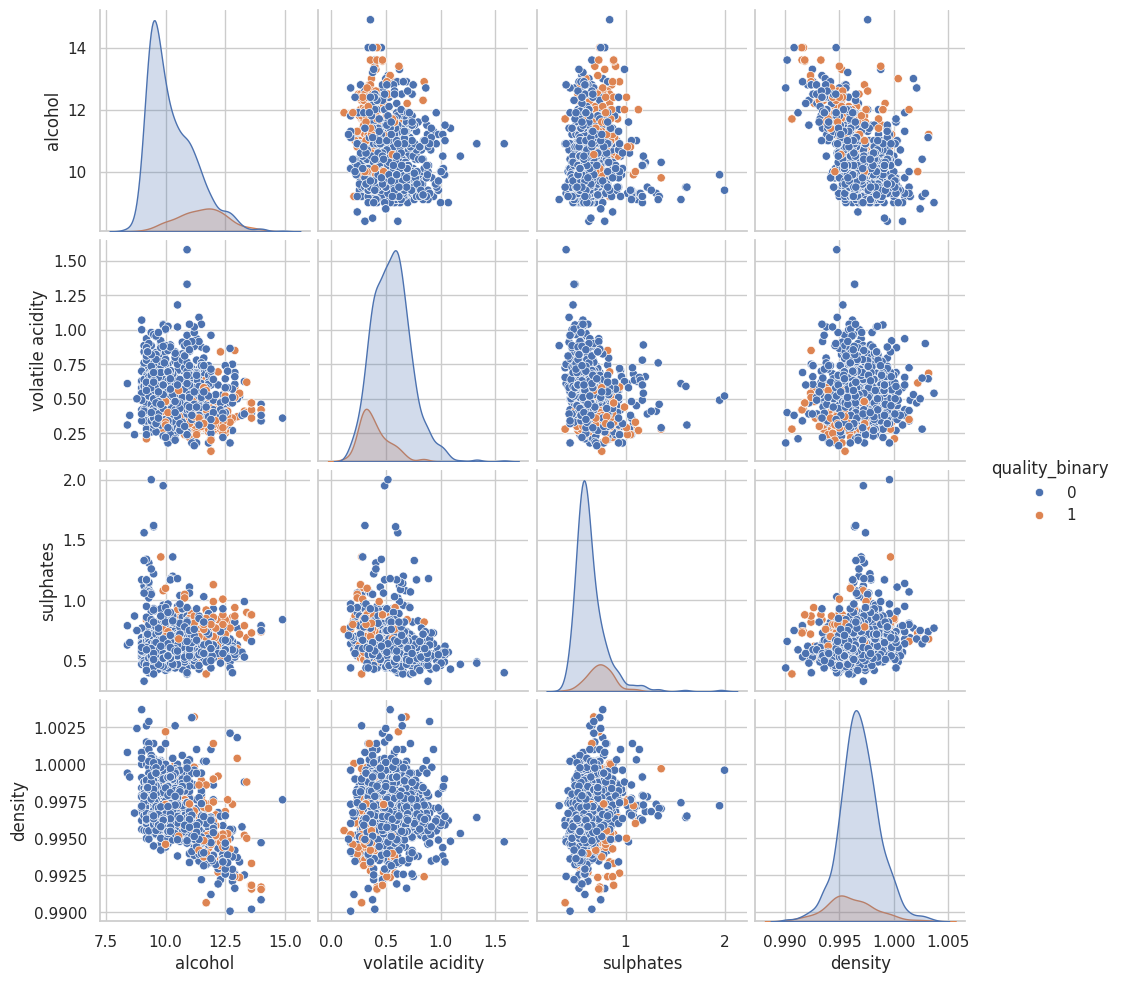

In [ ]:
sns.pairplot(
    df[
        [
            'alcohol',
            'volatile acidity',
            'sulphates',
            'density',
            'quality_binary'
        ]
    ],
    hue='quality_binary'
)
plt.show()


## 12. Conclusão da EDA

A análise exploratória mostrou que a base possui variáveis físico-químicas com distribuições diferentes, presença de possíveis outliers e classes desbalanceadas.

A variável alvo foi corretamente transformada em classificação binária por meio da criação da coluna `quality_binary`. A classe `0` representa vinhos com qualidade menor que 7, enquanto a classe `1` representa vinhos com qualidade maior ou igual a 7.

As variáveis `alcohol`, `volatile acidity`, `sulphates`, `citric acid` e `density` aparecem como importantes na análise de correlação com a qualidade binária. O álcool e os sulfatos tendem a se associar positivamente com vinhos de melhor qualidade, enquanto a acidez volátil e a densidade apresentam associação negativa.

A presença de desbalanceamento entre as classes deve ser observada na etapa de modelagem, pois pode impactar o desempenho do modelo e exigir métricas além da acurácia, como precisão, recall e F1-score.


## 13. Separação correta de variáveis para modelagem futura

A célula abaixo não treina nenhum modelo ainda. Ela apenas mostra a forma correta de separar as variáveis para a próxima etapa.

A coluna `quality` não deve ser usada como entrada do modelo, porque `quality_binary` foi criada a partir dela. Usar `quality` como variável explicativa causaria vazamento de informação.


In [ ]:
X = df.drop(columns=['Id', 'quality', 'quality_binary'])
y = df['quality_binary']

print('Formato de X:', X.shape)
print('Formato de y:', y.shape)


NameError: name 'df' is not defined

# 14. Pré-processamento para Modelagem

Antes de treinar os modelos, será preparada uma nova base chamada `df_pre`.

Nesta etapa, serão criadas novas variáveis por meio de feature engineering, os dados serão separados entre variáveis explicativas e variável alvo, a base será dividida em treino e teste e as variáveis numéricas serão padronizadas.

A padronização será feita após a separação entre treino e teste, evitando vazamento de dados. Isso significa que o `StandardScaler` será ajustado apenas nos dados de treino e depois aplicado aos dados de teste.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Cópia da base original
df_pre = df.copy()

# Garantia de que a variável alvo binária existe
if 'quality_binary' not in df_pre.columns:
    df_pre['quality_binary'] = np.where(df_pre['quality'] >= 7, 1, 0)

# Feature Engineering
df_pre['total_acidity'] = (
    df_pre['fixed acidity'] +
    df_pre['volatile acidity'] +
    df_pre['citric acid']
)

df_pre['free_sulfur_ratio'] = (
    df_pre['free sulfur dioxide'] / (df_pre['total sulfur dioxide'] + 1e-6)
)

df_pre['sugar_alcohol_ratio'] = (
    df_pre['residual sugar'] / (df_pre['alcohol'] + 1e-6)
)

df_pre['alcohol_sulphates'] = (
    df_pre['alcohol'] * df_pre['sulphates']
)

print("Novas features criadas:")
print([
    'total_acidity',
    'free_sulfur_ratio',
    'sugar_alcohol_ratio',
    'alcohol_sulphates'
])

display(df_pre.head())

ModuleNotFoundError: No module named 'sklearn'

Foram criadas quatro novas variáveis a partir das características originais da base.

A variável `total_acidity` representa a soma das principais variáveis relacionadas à acidez do vinho: acidez fixa, acidez volátil e ácido cítrico.

A variável `free_sulfur_ratio` representa a proporção de dióxido de enxofre livre em relação ao dióxido de enxofre total.

A variável `sugar_alcohol_ratio` compara o açúcar residual com o teor alcoólico, relação que pode estar ligada ao processo de fermentação.

A variável `alcohol_sulphates` representa uma interação entre álcool e sulfatos, duas variáveis que apresentaram relação com a qualidade durante a análise exploratória.

Essas novas variáveis foram criadas para enriquecer a base e permitir que os modelos identifiquem padrões que poderiam não aparecer diretamente nas variáveis originais.

In [ ]:
# Separando variáveis explicativas e variável alvo

# Removemos:
# quality -> variável original usada para criar quality_binary
# quality_binary -> variável alvo, não pode ficar dentro de X
# Id -> identificador da linha, sem valor preditivo

X = df_pre.drop(columns=['quality', 'quality_binary', 'Id'])
y = df_pre['quality_binary']

print("Formato das variáveis explicativas X:", X.shape)
print("Formato da variável alvo y:", y.shape)

Formato das variáveis explicativas X: (1143, 15)
Formato da variável alvo y: (1143,)


Nesta etapa, os dados foram separados entre variáveis explicativas e variável alvo.

A variável `X` contém as características usadas para tentar prever a qualidade do vinho. Foram removidas as colunas `quality`, `quality_binary` e `Id`.

A coluna `quality` foi removida porque foi usada para criar a classificação binária. Mantê-la no modelo causaria vazamento de informação. A coluna `quality_binary` foi removida porque é a própria variável alvo. Já a coluna `Id` foi removida porque é apenas um identificador e não possui significado preditivo.

A variável `y` contém a classe que o modelo deverá prever: 0 para vinhos de baixa/intermediária qualidade e 1 para vinhos de alta qualidade.

In [ ]:
# Separando treino e teste

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Dados separados em treino e teste:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Dados separados em treino e teste:
X_train: (914, 15)
X_test: (229, 15)
y_train: (914,)
y_test: (229,)


Os dados foram separados em treino e teste.

A base de treino será usada para os modelos aprenderem os padrões dos dados. A base de teste será usada para avaliar o desempenho dos modelos em dados que eles ainda não viram.

Foi utilizado `test_size=0.2`, ou seja, 80% dos dados foram destinados ao treino e 20% ao teste.

Também foi utilizado `stratify=y`, garantindo que a proporção entre as classes 0 e 1 seja mantida tanto no treino quanto no teste. Isso é importante porque a base está desbalanceada.

In [ ]:
# Padronização das variáveis numéricas

scaler = StandardScaler()

# Ajusta o scaler apenas nos dados de treino
X_train_scaled = scaler.fit_transform(X_train)

# Aplica a mesma transformação nos dados de teste
X_test_scaled = scaler.transform(X_test)

# Convertendo novamente para DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("Padronização concluída.")
display(X_train_scaled.describe().T[['mean', 'std']])

Padronização concluída.


,mean,std
fixed acidity,-3.187336e-16,1.000547
volatile acidity,-2.312762e-16,1.000547
citric acid,-2.720897e-17,1.000547
residual sugar,2.992986e-16,1.000547
chlorides,-5.247444e-17,1.000547
free sulfur dioxide,-4.664394e-17,1.000547
total sulfur dioxide,-3.109596e-17,1.000547
density,6.232797e-15,1.000547
pH,-1.360448e-17,1.000547
sulphates,2.487677e-16,1.000547


A padronização foi aplicada utilizando o `StandardScaler`.

Esse método transforma as variáveis para que fiquem com média próxima de 0 e desvio padrão próximo de 1. Isso é importante porque as variáveis da base possuem escalas diferentes.

O `StandardScaler` foi ajustado apenas nos dados de treino com `fit_transform`. Depois, a mesma transformação foi aplicada nos dados de teste com `transform`.

Essa ordem evita vazamento de dados, pois as informações do conjunto de teste não são usadas no momento de preparação dos dados de treino.

# 15. Desenvolvimento de Modelos

Nesta etapa, serão treinados dois modelos de classificação:

1. Regressão Logística.
2. Random Forest.

A Regressão Logística foi escolhida por ser um modelo simples, interpretável e adequado para problemas de classificação binária.

O Random Forest foi escolhido por ser um modelo baseado em várias árvores de decisão, capaz de capturar relações não lineares entre as variáveis.

Como a base está desbalanceada, foi usado `class_weight='balanced'` nos modelos. Esse parâmetro ajuda os modelos a darem mais atenção para a classe minoritária, que neste caso representa os vinhos de alta qualidade.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Modelo 1: Regressão Logística
modelo_log = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Modelo 2: Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    random_state=42
)

# Treinamento dos modelos
modelo_log.fit(X_train_scaled, y_train)
modelo_rf.fit(X_train, y_train)

print("Modelos treinados com sucesso.")

Modelos treinados com sucesso.


Os dois modelos foram treinados com os dados de treino.

A Regressão Logística foi treinada com os dados padronizados, pois esse tipo de modelo é sensível à escala das variáveis.

O Random Forest foi treinado com os dados originais, pois modelos baseados em árvores não exigem padronização para funcionar corretamente.

Com os modelos treinados, a próxima etapa é avaliar o desempenho de cada um usando métricas adequadas.

# 16. Avaliação dos Modelos

Como a base está desbalanceada, a avaliação não deve considerar apenas a acurácia.

Serão utilizadas as seguintes métricas:

Acurácia: mostra a proporção total de acertos do modelo.

Precisão: mostra, entre os vinhos previstos como alta qualidade, quantos realmente eram de alta qualidade.

Recall: mostra, entre os vinhos que realmente eram de alta qualidade, quantos o modelo conseguiu identificar.

F1-score: combina precisão e recall em uma única métrica.

ROC-AUC: mede a capacidade geral do modelo de separar as classes.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Predições
y_pred_log = modelo_log.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test)

# Probabilidades da classe 1
y_prob_log = modelo_log.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = modelo_rf.predict_proba(X_test)[:, 1]

# Função para avaliação
def avaliar_modelo(nome, y_real, y_pred, y_prob):
    return {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_real, y_pred),
        'Precisão': precision_score(y_real, y_pred, zero_division=0),
        'Recall': recall_score(y_real, y_pred, zero_division=0),
        'F1-score': f1_score(y_real, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_real, y_prob)
    }

resultados_modelos = pd.DataFrame([
    avaliar_modelo('Regressão Logística', y_test, y_pred_log, y_prob_log),
    avaliar_modelo('Random Forest', y_test, y_pred_rf, y_prob_rf)
])

resultados_modelos = resultados_modelos.set_index('Modelo').round(4)

display(resultados_modelos)

,Acurácia,Precisão,Recall,F1-score,ROC-AUC
Modelo,,,,,
Regressão Logística,0.7948,0.3684,0.6562,0.4719,0.8639
Random Forest,0.9170,0.8824,0.4688,0.6122,0.9007


A tabela apresenta a comparação entre os dois modelos testados.

Como a base está desbalanceada, a acurácia deve ser analisada com cuidado. Um modelo pode apresentar acurácia alta simplesmente por prever a classe majoritária com frequência.

Por isso, as métricas mais importantes para este problema são `Recall`, `F1-score` e `ROC-AUC`, principalmente porque a classe 1 representa os vinhos de alta qualidade, que são menos frequentes na base.

O melhor modelo deve ser escolhido considerando o equilíbrio entre essas métricas, e não apenas a acurácia.

In [ ]:
# Relatórios detalhados de classificação

print("Relatório de Classificação - Regressão Logística")
print(classification_report(y_test, y_pred_log, zero_division=0))

print("\nRelatório de Classificação - Random Forest")
print(classification_report(y_test, y_pred_rf, zero_division=0))

Relatório de Classificação - Regressão Logística
              precision    recall  f1-score   support

           0       0.94      0.82      0.87       197
           1       0.37      0.66      0.47        32

    accuracy                           0.79       229
   macro avg       0.65      0.74      0.67       229
weighted avg       0.86      0.79      0.82       229


Relatório de Classificação - Random Forest
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       197
           1       0.88      0.47      0.61        32

    accuracy                           0.92       229
   macro avg       0.90      0.73      0.78       229
weighted avg       0.91      0.92      0.91       229



O relatório de classificação apresenta as métricas separadas por classe.

A classe 0 representa vinhos de baixa ou intermediária qualidade. A classe 1 representa vinhos de alta qualidade.

A análise da classe 1 é especialmente importante, pois ela é a classe minoritária. Caso o modelo tenha baixo recall para a classe 1, significa que ele está deixando de identificar muitos vinhos de alta qualidade.

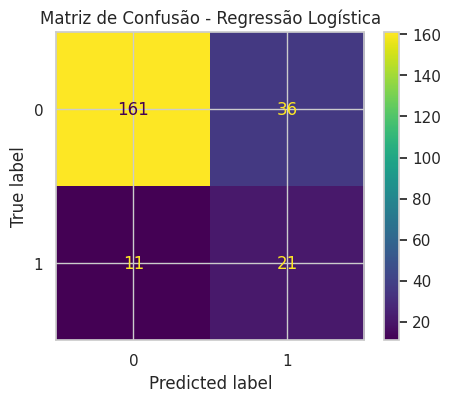

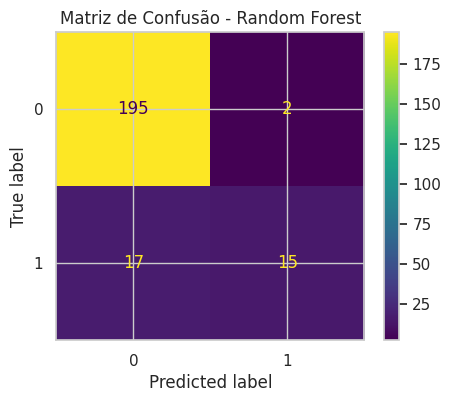

In [ ]:
# Matrizes de confusão

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_log,
    ax=ax,
    values_format='d'
)
plt.title('Matriz de Confusão - Regressão Logística')
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    ax=ax,
    values_format='d'
)
plt.title('Matriz de Confusão - Random Forest')
plt.show()

As matrizes de confusão mostram os acertos e erros dos modelos.

Os valores da diagonal principal representam as previsões corretas. Os valores fora da diagonal representam erros.

Para este problema, é importante observar quantos vinhos da classe 1 foram classificados corretamente e quantos foram classificados incorretamente como classe 0.

Esse ponto é relevante porque a classe 1 representa os vinhos de alta qualidade, que são menos frequentes na base.

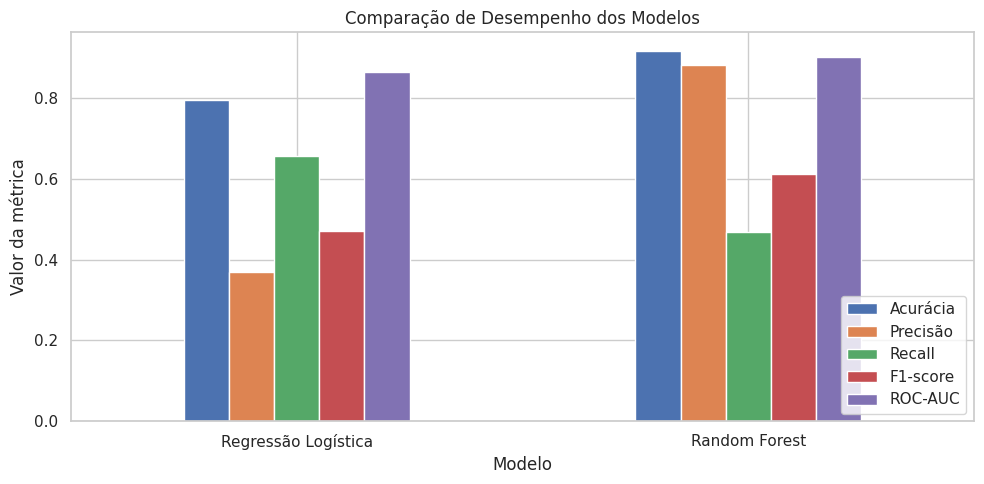

In [ ]:
# Comparação visual das métricas

resultados_modelos.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.title('Comparação de Desempenho dos Modelos')
plt.ylabel('Valor da métrica')
plt.xlabel('Modelo')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

O gráfico permite comparar visualmente o desempenho dos modelos em cada métrica.

Se um modelo tiver melhor acurácia, mas desempenho baixo em recall ou F1-score, ele pode não ser o mais adequado para este problema.

Como a base possui desbalanceamento de classes, o modelo mais interessante tende a ser aquele que apresenta melhor equilíbrio entre `F1-score`, `Recall` e `ROC-AUC`.

In [ ]:
# Identificando o melhor modelo com base no F1-score

melhor_modelo = resultados_modelos['F1-score'].idxmax()
melhor_f1 = resultados_modelos.loc[melhor_modelo, 'F1-score']

print(f"Melhor modelo pelo F1-score: {melhor_modelo}")
print(f"F1-score: {melhor_f1}")

Melhor modelo pelo F1-score: Random Forest
F1-score: 0.6122


O F1-score foi usado como critério principal de comparação porque ele equilibra precisão e recall.

Essa escolha é adequada para bases desbalanceadas, pois evita avaliar o modelo apenas pela acurácia.

Assim, o modelo com maior F1-score tende a apresentar melhor equilíbrio entre identificar corretamente os vinhos de alta qualidade e evitar classificações incorretas.

# 17. Interpretação dos Resultados

Nesta etapa, serão analisadas quais variáveis parecem ter maior influência na classificação da qualidade do vinho.

Para isso, serão usadas duas abordagens:

1. Coeficientes absolutos da Regressão Logística.
2. Importância das variáveis no Random Forest.

A Regressão Logística mostra a influência das variáveis em um modelo linear. O Random Forest mostra quais variáveis foram mais relevantes para as decisões das árvores.

In [ ]:
# Importância das variáveis na Regressão Logística

importancia_log = pd.DataFrame({
    'variavel': X_train.columns,
    'coeficiente': modelo_log.coef_[0],
    'coeficiente_absoluto': np.abs(modelo_log.coef_[0])
}).sort_values(by='coeficiente_absoluto', ascending=False)

display(importancia_log.head(10))

,variavel,coeficiente,coeficiente_absoluto
14,alcohol_sulphates,0.998676,0.998676
3,residual sugar,0.866714,0.866714
13,sugar_alcohol_ratio,-0.565207,0.565207
10,alcohol,0.487210,0.487210
1,volatile acidity,-0.471345,0.471345
2,citric acid,0.462877,0.462877
4,chlorides,-0.424460,0.424460
12,free_sulfur_ratio,0.324434,0.324434
7,density,-0.267291,0.267291
6,total sulfur dioxide,-0.255866,0.255866


A tabela acima mostra as variáveis com maior influência na Regressão Logística.

O valor absoluto do coeficiente indica a força da influência da variável no modelo. Já o sinal do coeficiente indica a direção da relação.

Coeficientes positivos indicam que o aumento daquela variável tende a aumentar a chance de o vinho ser classificado como alta qualidade.

Coeficientes negativos indicam que o aumento daquela variável tende a reduzir a chance de o vinho ser classificado como alta qualidade.

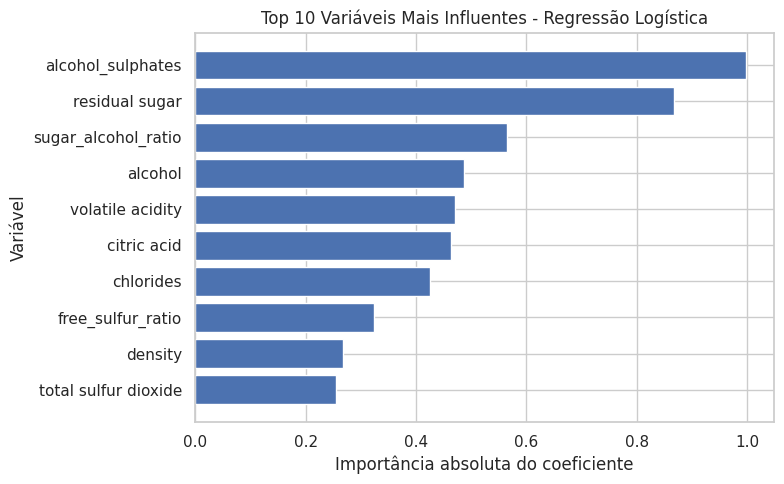

In [ ]:
# Gráfico dos coeficientes mais importantes da Regressão Logística

top_log = importancia_log.head(10).sort_values(by='coeficiente_absoluto')

plt.figure(figsize=(8, 5))
plt.barh(top_log['variavel'], top_log['coeficiente_absoluto'])
plt.title('Top 10 Variáveis Mais Influentes - Regressão Logística')
plt.xlabel('Importância absoluta do coeficiente')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

In [ ]:
# Importância das variáveis no Random Forest

importancia_rf = pd.DataFrame({
    'variavel': X_train.columns,
    'importancia': modelo_rf.feature_importances_
}).sort_values(by='importancia', ascending=False)

display(importancia_rf.head(10))

,variavel,importancia
14,alcohol_sulphates,0.159089
10,alcohol,0.150501
2,citric acid,0.096215
1,volatile acidity,0.095479
9,sulphates,0.081261
7,density,0.054100
6,total sulfur dioxide,0.050641
4,chlorides,0.046863
0,fixed acidity,0.045154
12,free_sulfur_ratio,0.044362


A tabela acima mostra a importância das variáveis no modelo Random Forest.

Quanto maior o valor de importância, maior foi a contribuição daquela variável para as decisões do modelo.

Essa análise ajuda a identificar quais características físico-químicas foram mais relevantes para separar vinhos de alta qualidade dos demais.

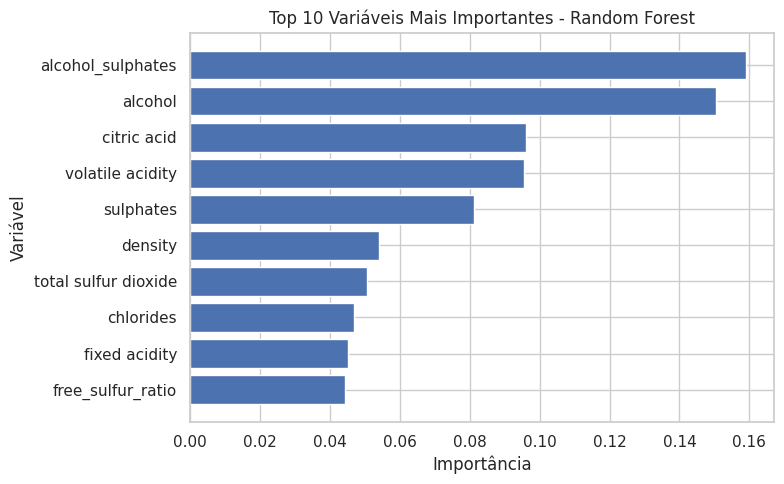

In [ ]:
# Gráfico das variáveis mais importantes no Random Forest

top_rf = importancia_rf.head(10).sort_values(by='importancia')

plt.figure(figsize=(8, 5))
plt.barh(top_rf['variavel'], top_rf['importancia'])
plt.title('Top 10 Variáveis Mais Importantes - Random Forest')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()

In [ ]:
# Comparação combinada de importância entre os dois modelos

comparacao_importancias = importancia_log[['variavel', 'coeficiente_absoluto']].merge(
    importancia_rf,
    on='variavel',
    how='inner'
)

comparacao_importancias['coeficiente_absoluto_norm'] = (
    comparacao_importancias['coeficiente_absoluto'] /
    comparacao_importancias['coeficiente_absoluto'].max()
)

comparacao_importancias['importancia_rf_norm'] = (
    comparacao_importancias['importancia'] /
    comparacao_importancias['importancia'].max()
)

comparacao_importancias['media_importancia'] = (
    comparacao_importancias['coeficiente_absoluto_norm'] +
    comparacao_importancias['importancia_rf_norm']
) / 2

comparacao_importancias = comparacao_importancias.sort_values(
    by='media_importancia',
    ascending=False
)

display(comparacao_importancias.head(10))

,variavel,coeficiente_absoluto,importancia,coeficiente_absoluto_norm,importancia_rf_norm,media_importancia
0,alcohol_sulphates,0.998676,0.159089,1.000000,1.000000,1.000000
3,alcohol,0.487210,0.150501,0.487856,0.946022,0.716939
4,volatile acidity,0.471345,0.095479,0.471970,0.600163,0.536066
5,citric acid,0.462877,0.096215,0.463491,0.604791,0.534141
1,residual sugar,0.866714,0.029974,0.867863,0.188408,0.528135
2,sugar_alcohol_ratio,0.565207,0.031393,0.565956,0.197331,0.381644
6,chlorides,0.424460,0.046863,0.425023,0.294572,0.359798
10,sulphates,0.195603,0.081261,0.195863,0.510794,0.353328
8,density,0.267291,0.054100,0.267646,0.340059,0.303852
7,free_sulfur_ratio,0.324434,0.044362,0.324864,0.278849,0.301857


A tabela combinada compara a importância das variáveis nos dois modelos.

Essa comparação é útil porque a Regressão Logística e o Random Forest funcionam de maneiras diferentes. Quando uma variável aparece como importante nos dois modelos, existe um indício mais forte de que ela tem relação relevante com a qualidade do vinho.

As variáveis que aparecerem entre as primeiras posições devem ser destacadas na interpretação final do trabalho.

# 18. Discussão dos Resultados e Implicações para Produção

Com base na análise exploratória e na interpretação dos modelos, algumas variáveis tendem a apresentar maior influência na classificação da qualidade do vinho.

A variável `alcohol` costuma ser uma das mais relevantes, indicando que o teor alcoólico pode estar associado a vinhos de melhor qualidade. Isso pode estar relacionado ao processo de fermentação, maturação e equilíbrio sensorial do vinho.

A variável `volatile acidity` também merece atenção. Valores mais altos de acidez volátil tendem a estar associados a menor qualidade, pois podem prejudicar aroma e sabor do vinho.

A variável `sulphates` pode indicar influência positiva na qualidade, possivelmente relacionada à conservação e estabilidade do vinho, desde que esteja em níveis adequados.

A variável `density` pode ter relação indireta com álcool e açúcar residual. Vinhos com maior teor alcoólico tendem a apresentar menor densidade, o que pode ajudar a explicar sua associação com a qualidade.

As novas features criadas, como `total_acidity`, `sugar_alcohol_ratio` e `alcohol_sulphates`, podem auxiliar na identificação de relações combinadas entre as variáveis originais.

Do ponto de vista do processo de produção, os resultados indicam que o controle de acidez, teor alcoólico, sulfatos, densidade e equilíbrio entre açúcar e álcool pode ser relevante para produzir vinhos com maior chance de serem avaliados como alta qualidade.

É importante destacar que os modelos mostram associações estatísticas, não relações de causa direta. Portanto, os resultados devem ser usados como apoio à tomada de decisão, e não como única explicação para a qualidade do vinho.